In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [143]:
df_store = pd.read_csv('/content/drive/MyDrive//idAI/dataset/store5.csv')
df_store.head()

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.0,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.0,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.0,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN
4,1456,2013-01-01,5,BOOKS,0.0,0,NaN


In [144]:
output_path = '/content/drive/MyDrive//idAI/dataset/store5.xlsx'
df_store.to_excel(output_path, index=False)

print(f"File converted and saved to: {output_path}")

File converted and saved to: /content/drive/MyDrive//idAI/dataset/store5.xlsx


In [145]:
def top_3_sales(df_store):
    family_sales = df_store.groupby('family')['sales'].sum().sort_values(ascending=False)

    return family_sales.head(3)

result = top_3_sales(df_store)
print(top_3_sales(df_store))

family
GROCERY I    5262681.658
BEVERAGES    2533831.000
CLEANING     1667748.000
Name: sales, dtype: float64


In [146]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           55572 non-null  int64  
 1   date         55572 non-null  object 
 2   store_nbr    55572 non-null  int64  
 3   family       55572 non-null  object 
 4   sales        55572 non-null  float64
 5   onpromotion  55572 non-null  int64  
 6   dcoilwtico   38379 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.0+ MB


In [147]:
df_store.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
dcoilwtico,17193


In [148]:
df_store['date'] = pd.to_datetime(df_store['date']) #mengubah tipe data di kolom date dari object, menjadi datetime

In [149]:
#mengisi row nan dengan metode interpolasi
df_store['dcoilwtico_interpolate'] = df_store['dcoilwtico']
df_store

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN,NaN
...,...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57,47.57


In [150]:
# interpolasi data yang hilang menggunakan metode polinomial dengan urutan 2
# mengisi nilai NaN yang mungkin tersisa dalam kolom dcoilwtico_interpolate dengan metode ffill (forward fill)
df_store['dcoilwtico_interpolate'] = df_store['dcoilwtico'].interpolate(method='polynomial', order=2)
df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)
df_store.head()

<ipython-input-150-fb12136b4ad1>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)
<ipython-input-150-fb12136b4ad1>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)


,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,1452,2013-01-01,5,AUTOMOTIVE,0.0,0,NaN,NaN
1,1453,2013-01-01,5,BABY CARE,0.0,0,NaN,NaN
2,1454,2013-01-01,5,BEAUTY,0.0,0,NaN,NaN
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN,NaN
4,1456,2013-01-01,5,BOOKS,0.0,0,NaN,NaN


In [151]:
df_store.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
dcoilwtico,17193
dcoilwtico_interpolate,33


In [152]:
# mengisi nilai NaN yang tersisa dalam kolom dcoilwtico_interpolate moted backward fill dan forward fill
df_store['dcoilwtico_interpolate'] = df_store['dcoilwtico_interpolate'].ffill()
df_store['dcoilwtico_interpolate'] = df_store['dcoilwtico_interpolate'].bfill()

In [153]:
df_store.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
dcoilwtico,17193
dcoilwtico_interpolate,0


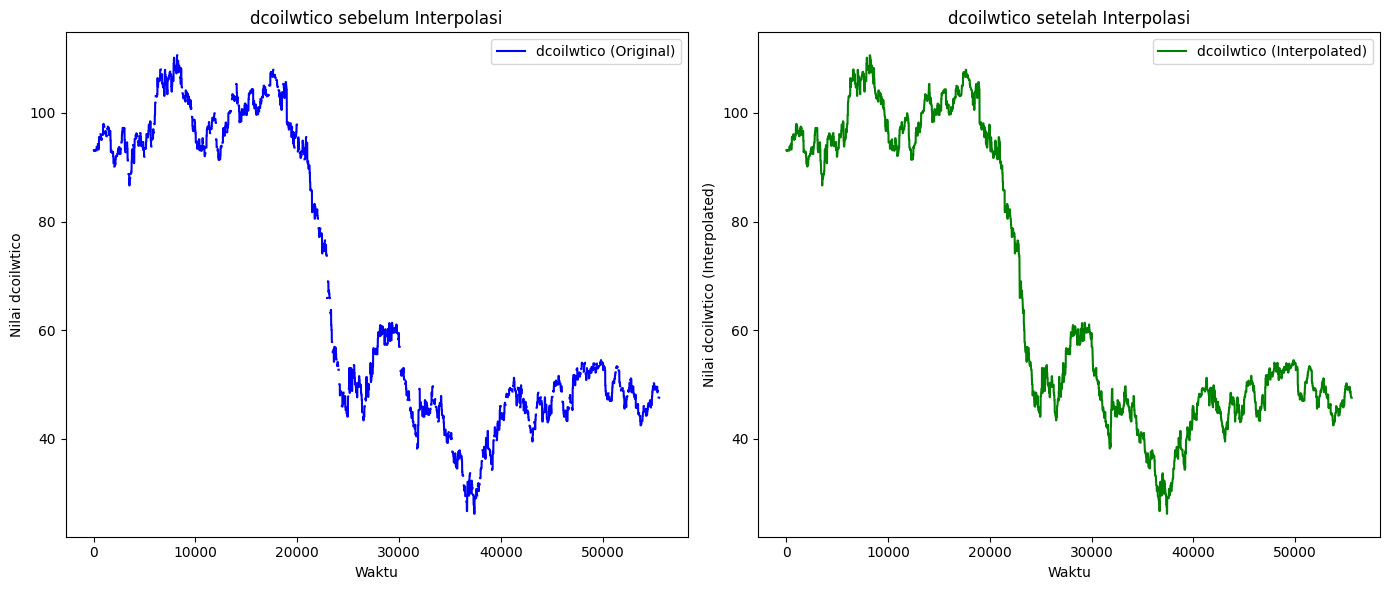

In [154]:
# Membuat plot perbandingan sebelum dan sesudah interpolasi
plt.figure(figsize=(14, 6))

# Plot dcoilwtico sebelum interpolasi
plt.subplot(1, 2, 1)
plt.plot(df_store['dcoilwtico'], label='dcoilwtico (Original)', color='blue')
plt.title('dcoilwtico sebelum Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico')
plt.legend()

# Plot dcoilwtico setelah fill mean
plt.subplot(1, 2, 2)
plt.plot(df_store['dcoilwtico_interpolate'], label='dcoilwtico (Interpolated)', color='green')
plt.title('dcoilwtico setelah Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico (Interpolated)')
plt.legend()

plt.tight_layout()
plt.show()

In [155]:
correlation = df_store[['sales', 'onpromotion', 'dcoilwtico_interpolate']].corr()
correlation

,sales,onpromotion,dcoilwtico_interpolate
sales,1.000000,0.448904,-0.041183
onpromotion,0.448904,1.000000,-0.158960
dcoilwtico_interpolate,-0.041183,-0.158960,1.000000


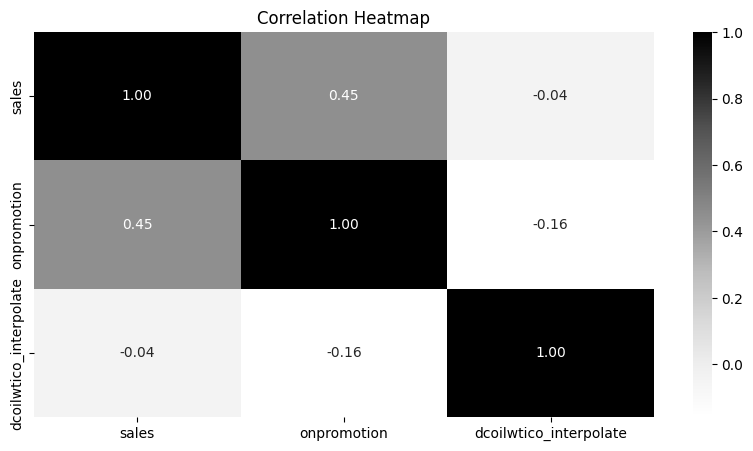

In [156]:

plt.figure(figsize=(10, 5))
sns.heatmap(correlation, annot=True, cmap='Greys', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [157]:
df_cleaning = df_store[df_store['family'] =='CLEANING']

In [158]:
df_cleaning

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
7,1459,2013-01-01,5,CLEANING,0.0,0,NaN,93.140000
40,3241,2013-01-02,5,CLEANING,1810.0,0,93.14,93.140000
73,5023,2013-01-03,5,CLEANING,1305.0,0,92.97,92.970000
106,6805,2013-01-04,5,CLEANING,1159.0,0,93.12,93.120000
139,8587,2013-01-05,5,CLEANING,1257.0,0,NaN,93.122431
...,...,...,...,...,...,...,...,...
55414,2993437,2017-08-11,5,CLEANING,775.0,16,48.81,48.810000
55447,2995219,2017-08-12,5,CLEANING,686.0,14,NaN,48.772921
55480,2997001,2017-08-13,5,CLEANING,927.0,16,NaN,47.959631
55513,2998783,2017-08-14,5,CLEANING,676.0,10,47.59,47.590000


In [159]:
df_cleaning = df_cleaning[['date','store_nbr','family','sales','onpromotion','dcoilwtico']]

In [160]:
full_date_range = pd.date_range(start=df_cleaning['date'].min(), end=df_cleaning['date'].max())

In [161]:
missing_dates = full_date_range[~full_date_range.isin(df_cleaning['date'])]
missing_dates

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

In [162]:
df_december = df_cleaning[df_cleaning['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
11029,2013-12-01,5,CLEANING,1551.0,0,NaN
11062,2013-12-02,5,CLEANING,906.0,0,93.61
11095,2013-12-03,5,CLEANING,867.0,0,95.83
11128,2013-12-04,5,CLEANING,966.0,0,96.97
11161,2013-12-05,5,CLEANING,911.0,0,97.14
11194,2013-12-06,5,CLEANING,809.0,0,97.48
11227,2013-12-07,5,CLEANING,991.0,0,NaN
11260,2013-12-08,5,CLEANING,1286.0,0,NaN
11293,2013-12-09,5,CLEANING,933.0,0,97.10
11326,2013-12-10,5,CLEANING,718.0,0,98.32


In [163]:
# missing di store_nbr diisi 5 dan family sesuai variable
df_cleaning['store_nbr'] = df_cleaning['store_nbr'].fillna(5).astype(int)
df_cleaning['family'] = df_cleaning['family'].fillna('CLEANING')

df_cleaning

<ipython-input-163-0bf20544d7df>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning['store_nbr'] = df_cleaning['store_nbr'].fillna(5).astype(int)
<ipython-input-163-0bf20544d7df>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning['family'] = df_cleaning['family'].fillna('CLEANING')


,date,store_nbr,family,sales,onpromotion,dcoilwtico
7,2013-01-01,5,CLEANING,0.0,0,NaN
40,2013-01-02,5,CLEANING,1810.0,0,93.14
73,2013-01-03,5,CLEANING,1305.0,0,92.97
106,2013-01-04,5,CLEANING,1159.0,0,93.12
139,2013-01-05,5,CLEANING,1257.0,0,NaN
...,...,...,...,...,...,...
55414,2017-08-11,5,CLEANING,775.0,16,48.81
55447,2017-08-12,5,CLEANING,686.0,14,NaN
55480,2017-08-13,5,CLEANING,927.0,16,NaN
55513,2017-08-14,5,CLEANING,676.0,10,47.59


Text(0.5, 1.0, 'dcoilwtico vs onpromotion')

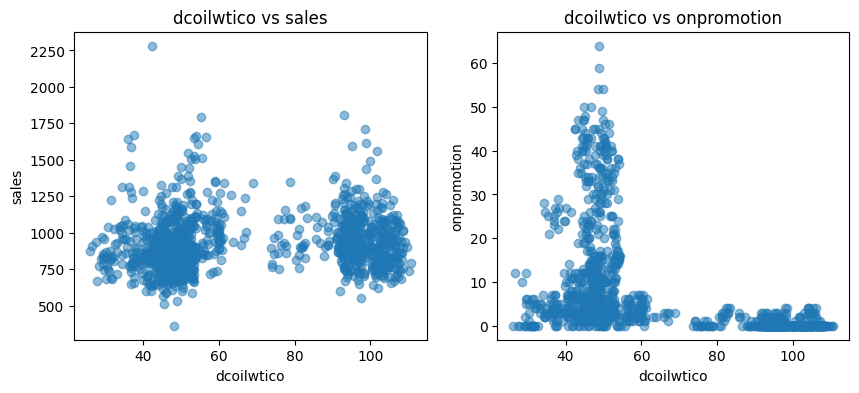

In [164]:
# scatterplot dcoilwtice vs sales
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(df_cleaning["dcoilwtico"], df_cleaning["sales"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("sales")
plt.title("dcoilwtico vs sales")

# scatterplot dcoilwtico vs onpromotion
plt.subplot(1, 2, 2)
plt.scatter(df_cleaning["dcoilwtico"], df_cleaning["onpromotion"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("onpromotion")
plt.title("dcoilwtico vs onpromotion")

In [165]:
df_cleaning.loc[:, 'dcoilwtico_interpolate'] = (
    df_cleaning['dcoilwtico']
    .interpolate(method='polynomial', order=2)
    .bfill()
)

<ipython-input-165-4ebbf5a06892>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning.loc[:, 'dcoilwtico_interpolate'] = (


In [166]:
df_cleaning.isna().sum()

,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
dcoilwtico,521
dcoilwtico_interpolate,0


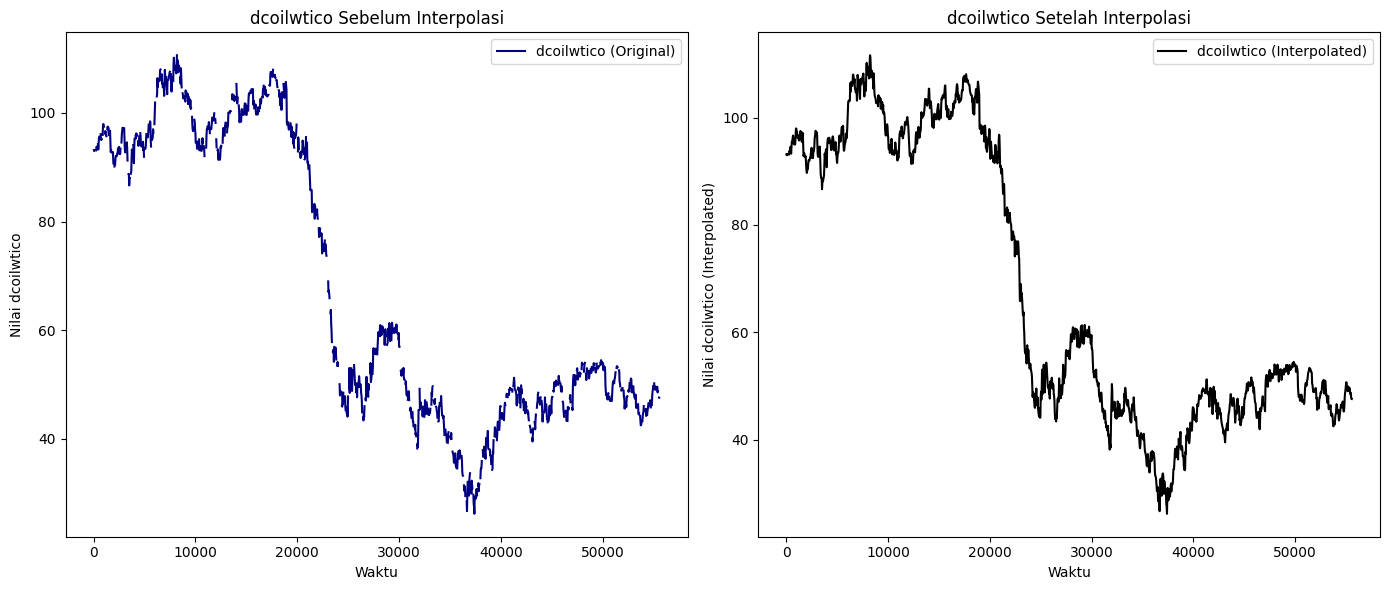

In [167]:
plt.figure(figsize=(14, 6))

# Plot dcoilwtico sebelum interpolasi
plt.subplot(1, 2, 1)
plt.plot(df_cleaning['dcoilwtico'], label='dcoilwtico (Original)', color='navy')
plt.title('dcoilwtico Sebelum Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico')
plt.legend()

# Plot dcoilwtico setelah interpolasi
plt.subplot(1, 2, 2)
plt.plot(df_cleaning['dcoilwtico_interpolate'], label='dcoilwtico (Interpolated)', color='black')
plt.title('dcoilwtico Setelah Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico (Interpolated)')
plt.legend()

plt.tight_layout()
plt.show()

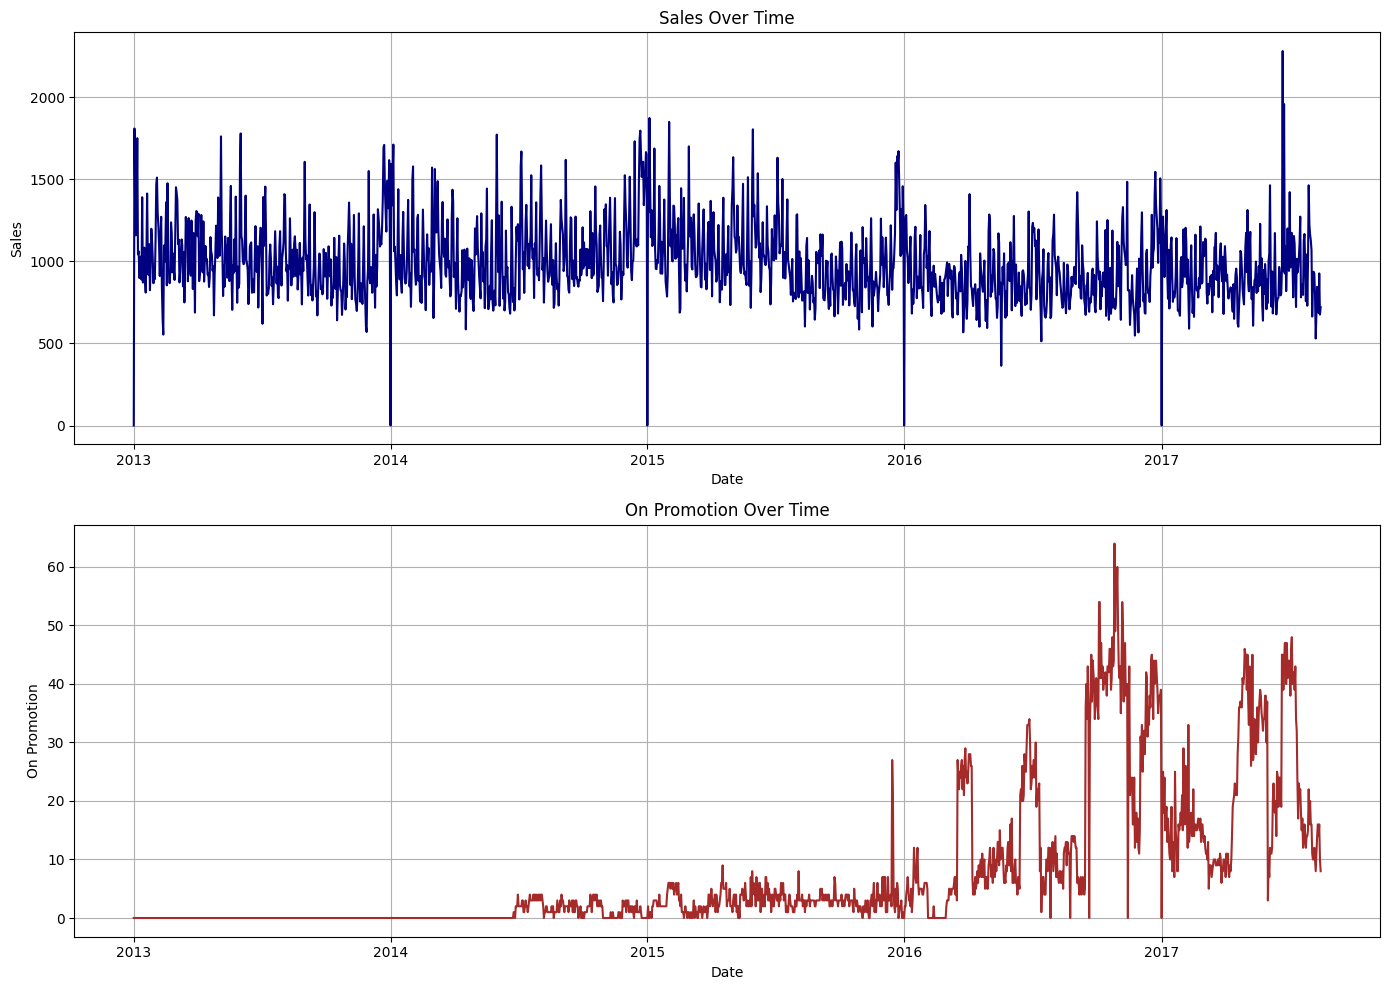

In [168]:
plt.style.use('default')

plt.figure(figsize=(14, 10), facecolor='white')

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(df_cleaning['date'], df_cleaning['sales'], color='navy')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion
plt.subplot(2, 1, 2)
plt.plot(df_cleaning['date'], df_cleaning['onpromotion'], color='brown')
plt.title("On Promotion Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

plt.tight_layout()
plt.show()

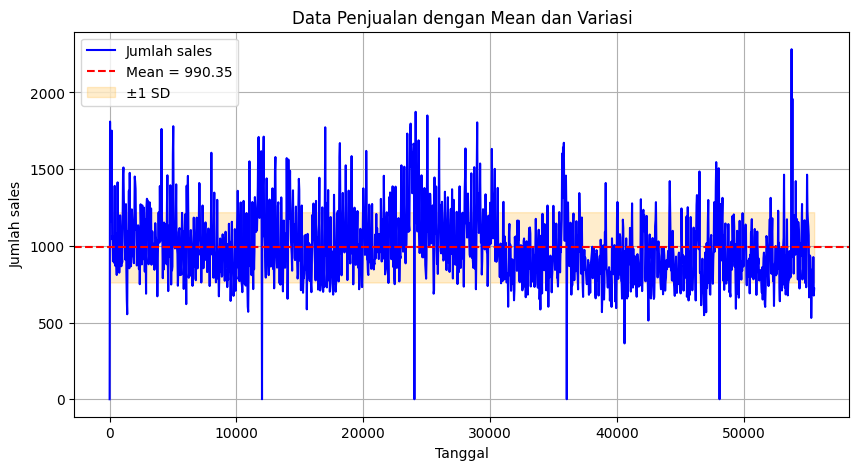

In [169]:

# Hitung Mean dan Standar Deviasi
mean_value =  df_cleaning['sales'].mean()
std_value =  df_cleaning['sales'].std()

# Plot Data Penjualan
plt.figure(figsize=(10, 5))
plt.plot( df_cleaning['sales'], label='Jumlah sales', color='blue')

# Tambahkan Garis Mean
plt.axhline(y=mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')

# Tambahkan Area Variasi (±1 Standar Deviasi)
plt.fill_between(
    df_cleaning.index,
    mean_value - std_value,
    mean_value + std_value,
    color='orange',
    alpha=0.2,
    label='±1 SD'
)

# Tambahkan Detail dan Keterangan
plt.title('Data Penjualan dengan Mean dan Variasi')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah sales')
plt.grid(True)
plt.legend()
plt.show()

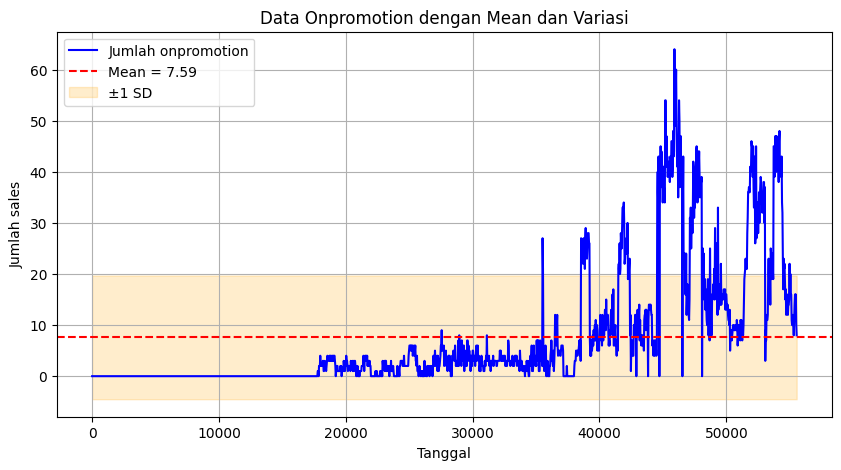

In [170]:
# Hitung Mean dan Standar Deviasi
mean_value =  df_cleaning['onpromotion'].mean()
std_value =  df_cleaning['onpromotion'].std()

# Plot Data Penjualan
plt.figure(figsize=(10, 5))
plt.plot( df_cleaning['onpromotion'], label='Jumlah onpromotion', color='blue')

# Tambahkan Garis Mean
plt.axhline(y=mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')

# Tambahkan Area Variasi (±1 Standar Deviasi)
plt.fill_between(
    df_cleaning.index,
    mean_value - std_value,
    mean_value + std_value,
    color='orange',
    alpha=0.2,
    label='±1 SD'
)

# Tambahkan Detail dan Keterangan
plt.title('Data Onpromotion dengan Mean dan Variasi')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah sales')
plt.grid(True)
plt.legend()
plt.show()

In [171]:

from statsmodels.tsa.stattools import adfuller

# Fungsi untuk ADF Test dan menampilkan hasil lengkap
def adf_test(series, series_name="Time Series"):
    result = adfuller(series.dropna())
    print(f"ADF Test for {series_name}:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print("=> Data is stationary (reject H0)")
    else:
        print("=> Data is non-stationary (fail to reject H0)")

# Contoh ADF test untuk sales dan onpromotion
adf_test(df_cleaning['sales'], "Sales")
adf_test(df_cleaning['onpromotion'], "OnPromotion")


ADF Test for Sales:
ADF Statistic: -5.4108
p-value: 0.0000
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677
=> Data is stationary (reject H0)
ADF Test for OnPromotion:
ADF Statistic: -2.7670
p-value: 0.0632
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677
=> Data is non-stationary (fail to reject H0)


In [172]:
df_cleaning['onpromotion_diff'] = df_cleaning['onpromotion'].diff()
df_cleaning

,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_diff
7,2013-01-01,5,CLEANING,0.0,0,NaN,93.140000,NaN
40,2013-01-02,5,CLEANING,1810.0,0,93.14,93.140000,0.0
73,2013-01-03,5,CLEANING,1305.0,0,92.97,92.970000,0.0
106,2013-01-04,5,CLEANING,1159.0,0,93.12,93.120000,0.0
139,2013-01-05,5,CLEANING,1257.0,0,NaN,93.205338,0.0
...,...,...,...,...,...,...,...,...
55414,2017-08-11,5,CLEANING,775.0,16,48.81,48.810000,2.0
55447,2017-08-12,5,CLEANING,686.0,14,NaN,48.717426,-2.0
55480,2017-08-13,5,CLEANING,927.0,16,NaN,48.020802,2.0
55513,2017-08-14,5,CLEANING,676.0,10,47.59,47.590000,-6.0


In [173]:
# Uji ADF untuk mengecek stasioneritas
result = adfuller(df_cleaning['onpromotion_diff'].dropna())

# Print hasil ADF Test
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# Jika p-value > 0.05, berarti tidak stasioner
if result[1] > 0.05:
    print("Data tidak stasioner, perlu differencing.")
else:
    print("Data sudah stasioner.")

ADF Statistic: -11.025336816933917
p-value: 5.847416317253584e-20
Data sudah stasioner.


In [174]:
full_date_range = pd.date_range(start=df_cleaning['date'].min(), end=df_cleaning['date'].max(), freq='D')

missing_dates = full_date_range.difference(df_cleaning['date'])
missing_dates

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

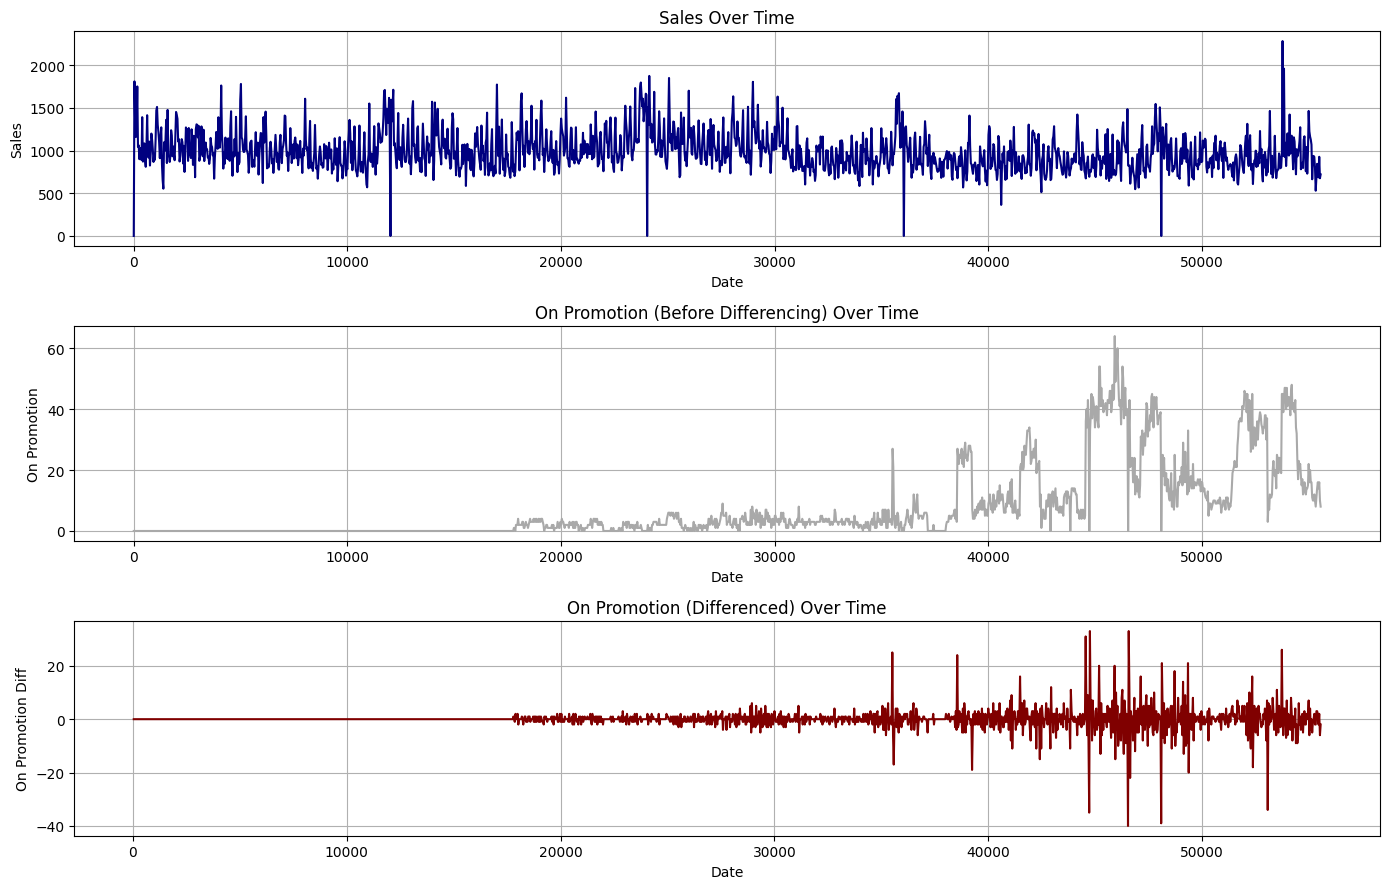

In [175]:
plt.figure(figsize=(14, 9))

# Plot Sales
plt.subplot(3, 1, 1)
plt.plot(df_cleaning.index, df_cleaning['sales'], color='navy')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion (Before Differencing)
plt.subplot(3, 1, 2)
plt.plot(df_cleaning.index, df_cleaning['onpromotion'], color='darkgray')
plt.title("On Promotion (Before Differencing) Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

# Plot On Promotion (Differenced)
plt.subplot(3, 1, 3)
plt.plot(df_cleaning.index, df_cleaning['onpromotion_diff'], color='maroon')
plt.title("On Promotion (Differenced) Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion Diff")
plt.grid(True)

plt.tight_layout()
plt.show()

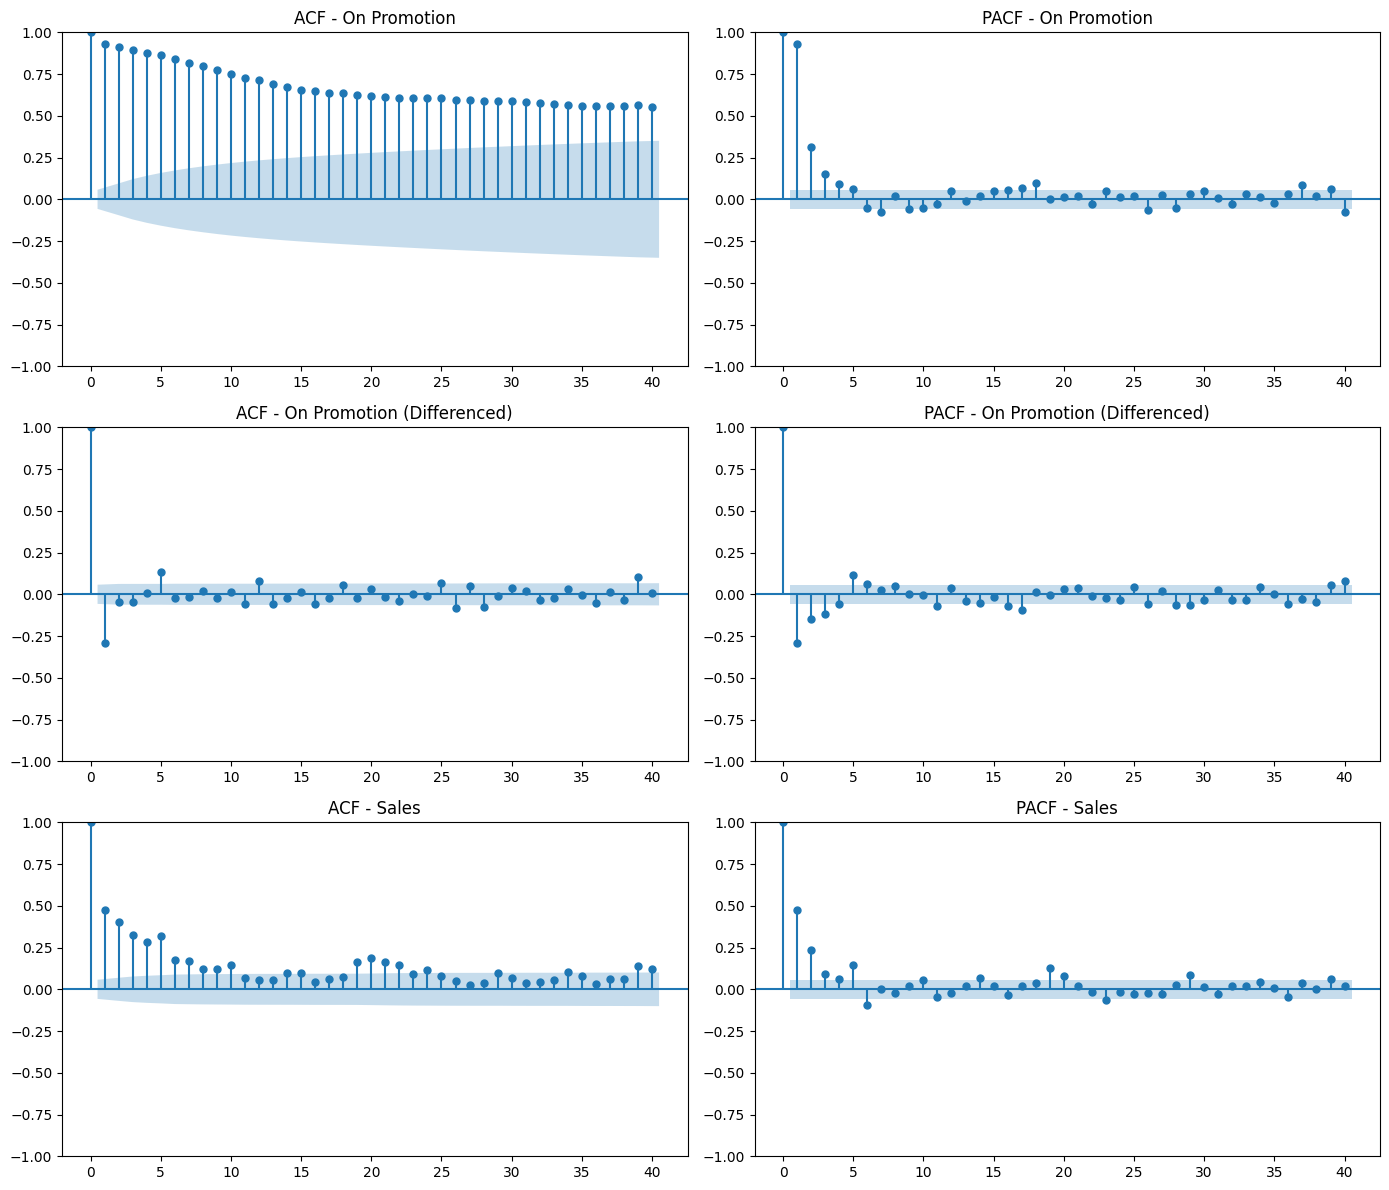

In [176]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Pastikan tanggal dalam format datetime
df_cleaning['date'] = pd.to_datetime(df_cleaning['date'])
df_cleaning.set_index('date', inplace=True)

# Lakukan differencing untuk onpromotion
df_cleaning['onpromotion_diff'] = df_cleaning['onpromotion'].diff()

# Drop NaN akibat differencing
df_cleaning.dropna(inplace=True)


fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# ACF & PACF On Promotion (Sebelum Differencing)
plot_acf(df_cleaning['onpromotion'], lags=40, ax=axes[0, 0])
axes[0, 0].set_title("ACF - On Promotion")

plot_pacf(df_cleaning['onpromotion'], lags=40, ax=axes[0, 1])
axes[0, 1].set_title("PACF - On Promotion")

# ACF & PACF On Promotion (Setelah Differencing)
plot_acf(df_cleaning['onpromotion_diff'], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF - On Promotion (Differenced)")

plot_pacf(df_cleaning['onpromotion_diff'], lags=40, ax=axes[1, 1])
axes[1, 1].set_title("PACF - On Promotion (Differenced)")

# ACF & PACF Sales
plot_acf(df_cleaning['sales'], lags=40, ax=axes[2, 0])
axes[2, 0].set_title("ACF - Sales")

plot_pacf(df_cleaning['sales'], lags=40, ax=axes[2, 1])
axes[2, 1].set_title("PACF - Sales")

plt.tight_layout()
plt.show()

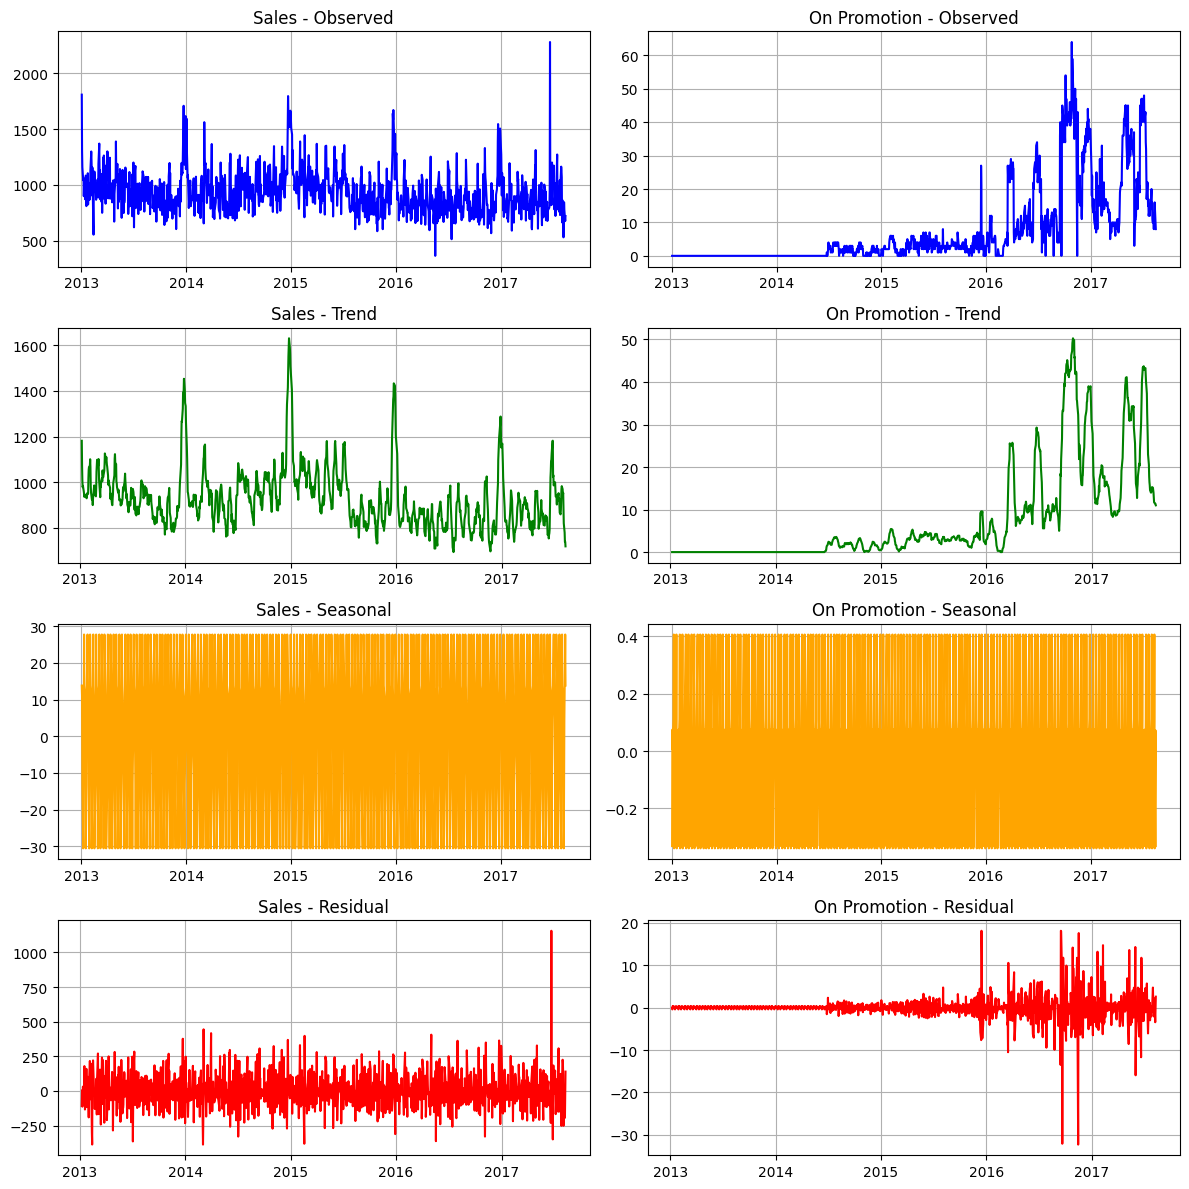

In [177]:

from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose Sales dan On Promotion
decomp_sales = seasonal_decompose(df_cleaning['sales'], model='additive', period=7)
decomp_onpromo = seasonal_decompose(df_cleaning['onpromotion'], model='additive', period=7)

fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Warna untuk membedakan setiap plot
colors = ['blue', 'green', 'orange', 'red']

# Sales Decomposition
axes[0, 0].plot(decomp_sales.observed, color=colors[0])
axes[0, 0].set_title("Sales - Observed")
axes[1, 0].plot(decomp_sales.trend, color=colors[1])
axes[1, 0].set_title("Sales - Trend")
axes[2, 0].plot(decomp_sales.seasonal, color=colors[2])
axes[2, 0].set_title("Sales - Seasonal")
axes[3, 0].plot(decomp_sales.resid, color=colors[3])
axes[3, 0].set_title("Sales - Residual")

# On Promotion Decomposition
axes[0, 1].plot(decomp_onpromo.observed, color=colors[0])
axes[0, 1].set_title("On Promotion - Observed")
axes[1, 1].plot(decomp_onpromo.trend, color=colors[1])
axes[1, 1].set_title("On Promotion - Trend")
axes[2, 1].plot(decomp_onpromo.seasonal, color=colors[2])
axes[2, 1].set_title("On Promotion - Seasonal")
axes[3, 1].plot(decomp_onpromo.resid, color=colors[3])
axes[3, 1].set_title("On Promotion - Residual")

# Tambahkan grid untuk memperjelas pola
for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

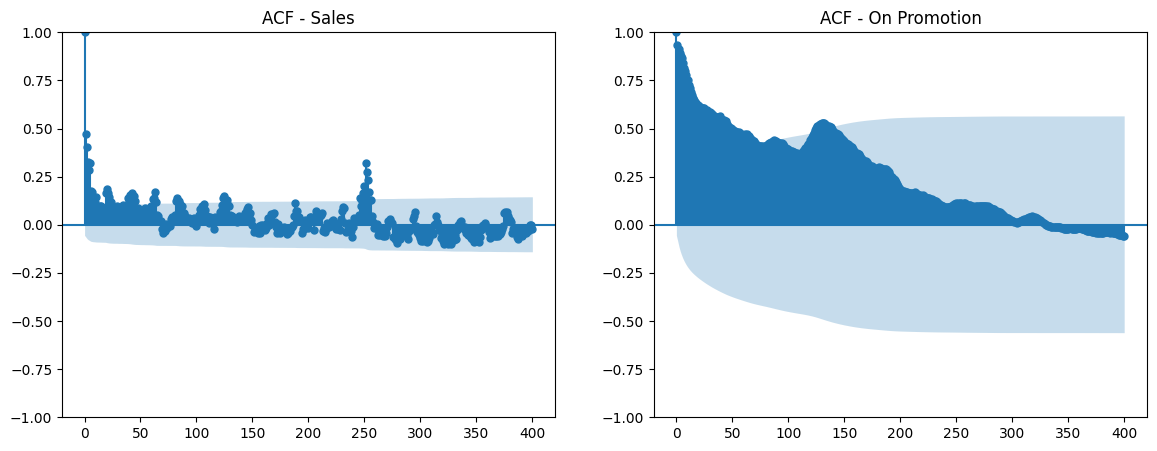

In [178]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF Sales
plot_acf(df_cleaning['sales'], lags=400, ax=axes[0])
axes[0].set_title("ACF - Sales")

# ACF On Promotion
plot_acf(df_cleaning['onpromotion'], lags=400, ax=axes[1])
axes[1].set_title("ACF - On Promotion")

plt.show()

In [179]:
df_cleaning

,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_diff
date,,,,,,,
2013-01-02,5,CLEANING,1810.0,0,93.14,93.14,0.0
2013-01-03,5,CLEANING,1305.0,0,92.97,92.97,0.0
2013-01-04,5,CLEANING,1159.0,0,93.12,93.12,0.0
2013-01-07,5,CLEANING,1043.0,0,93.20,93.20,0.0
2013-01-08,5,CLEANING,1062.0,0,93.21,93.21,0.0
...,...,...,...,...,...,...,...
2017-08-09,5,CLEANING,687.0,11,49.59,49.59,3.0
2017-08-10,5,CLEANING,845.0,14,48.54,48.54,3.0
2017-08-11,5,CLEANING,775.0,16,48.81,48.81,2.0


In [180]:
from statsmodels.tsa.stattools import acf

acf_values = acf(df_cleaning['sales'], nlags=1100, fft=False)

acf_df = pd.DataFrame({'Lag': np.arange(len(acf_values)), 'ACF_Sales': acf_values})

n = len(df_cleaning['sales'])

conf_interval = 1.96 / np.sqrt(n)

acf_df['Lower_Bound'] = -conf_interval
acf_df['Upper_Bound'] = conf_interval

acf_yearly = acf_df[acf_df['Lag'].isin([365, 730, 1095])]

acf_yearly['Significant'] = (acf_yearly['ACF_Sales'] > acf_yearly['Upper_Bound']) | (acf_yearly['ACF_Sales'] < acf_yearly['Lower_Bound'])

acf_yearly

<ipython-input-180-7ce8bebd01d1>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acf_yearly['Significant'] = (acf_yearly['ACF_Sales'] > acf_yearly['Upper_Bound']) | (acf_yearly['ACF_Sales'] < acf_yearly['Lower_Bound'])


,Lag,ACF_Sales,Lower_Bound,Upper_Bound,Significant
365,365,-0.049408,-0.057473,0.057473,False
730,730,-0.026397,-0.057473,0.057473,False
1095,1095,-0.007264,-0.057473,0.057473,False


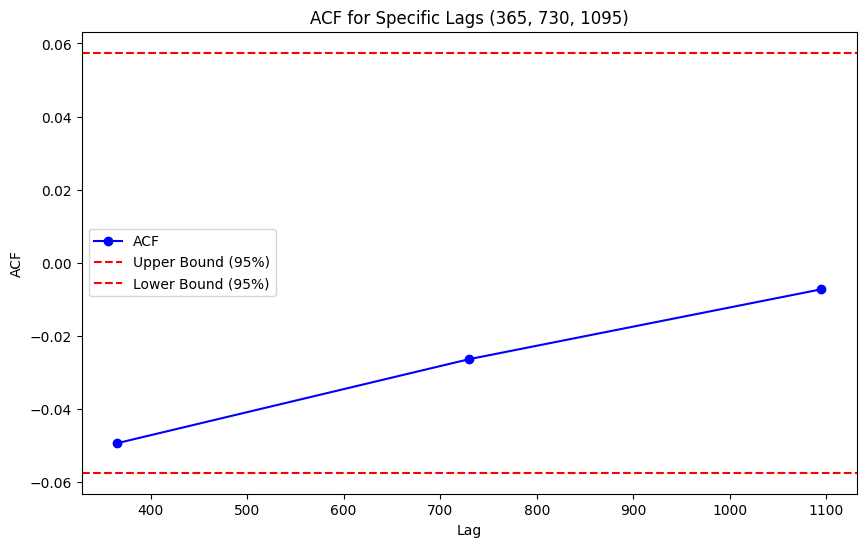

In [181]:
acf_yearly = acf_df[acf_df['Lag'].isin([365, 730, 1095])]

plt.figure(figsize=(10, 6))
plt.plot(acf_yearly['Lag'], acf_yearly['ACF_Sales'], marker='o', color='b', label='ACF')


plt.axhline(y=1.96/np.sqrt(n), color='r', linestyle='--', label='Upper Bound (95%)')
plt.axhline(y=-1.96/np.sqrt(n), color='r', linestyle='--', label='Lower Bound (95%)')

plt.title('ACF for Specific Lags (365, 730, 1095)')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.legend()

plt.show()

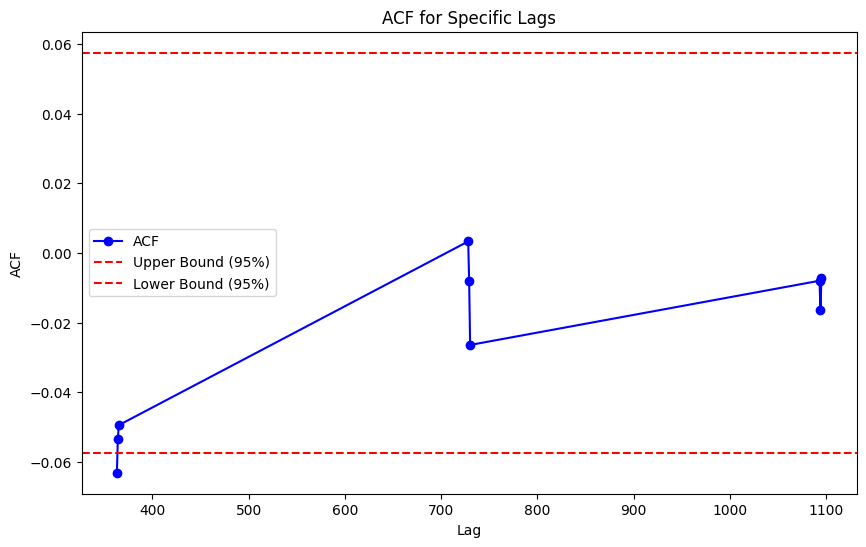

In [182]:
acf_somelags = acf_df[acf_df['Lag'].isin([363, 364, 365, 728, 729, 730, 1093, 1094, 1095])]

plt.figure(figsize=(10, 6))
plt.plot(acf_somelags['Lag'], acf_somelags['ACF_Sales'], marker='o', color='b', label='ACF')

plt.axhline(y=1.96/np.sqrt(n), color='r', linestyle='--', label='Upper Bound (95%)')
plt.axhline(y=-1.96/np.sqrt(n), color='r', linestyle='--', label='Lower Bound (95%)')

plt.title('ACF for Specific Lags')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.legend()

plt.show()

In [183]:
df_cleaning

,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_diff
date,,,,,,,
2013-01-02,5,CLEANING,1810.0,0,93.14,93.14,0.0
2013-01-03,5,CLEANING,1305.0,0,92.97,92.97,0.0
2013-01-04,5,CLEANING,1159.0,0,93.12,93.12,0.0
2013-01-07,5,CLEANING,1043.0,0,93.20,93.20,0.0
2013-01-08,5,CLEANING,1062.0,0,93.21,93.21,0.0
...,...,...,...,...,...,...,...
2017-08-09,5,CLEANING,687.0,11,49.59,49.59,3.0
2017-08-10,5,CLEANING,845.0,14,48.54,48.54,3.0
2017-08-11,5,CLEANING,775.0,16,48.81,48.81,2.0


In [184]:
from scipy.stats import boxcox

df_cleaning_new = df_store[['date','store_nbr','family','sales','onpromotion','dcoilwtico']]

In [185]:
df_cleaning_new = df_store[df_store["family"] == "CLEANING"]

df_cleaning_new = df_cleaning_new.set_index('date').reindex(full_date_range).reset_index()

df_cleaning_new.rename(columns={'index': 'date'}, inplace=True)

df_cleaning_new[['sales', 'onpromotion']] = df_cleaning_new[['sales', 'onpromotion']].fillna(0)

df_cleaning_new['store_nbr'] = df_cleaning_new['store_nbr'].fillna(5).astype(int)
df_cleaning_new['family'] = df_cleaning_new['family'].fillna("CLEANING")

In [186]:
df_cleaning_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,2013-01-01,1459.0,5,CLEANING,0.0,0.0,NaN,93.140000
1,2013-01-02,3241.0,5,CLEANING,1810.0,0.0,93.14,93.140000
2,2013-01-03,5023.0,5,CLEANING,1305.0,0.0,92.97,92.970000
3,2013-01-04,6805.0,5,CLEANING,1159.0,0.0,93.12,93.120000
4,2013-01-05,8587.0,5,CLEANING,1257.0,0.0,NaN,93.122431
...,...,...,...,...,...,...,...,...
1683,2017-08-11,2993437.0,5,CLEANING,775.0,16.0,48.81,48.810000
1684,2017-08-12,2995219.0,5,CLEANING,686.0,14.0,NaN,48.772921
1685,2017-08-13,2997001.0,5,CLEANING,927.0,16.0,NaN,47.959631
1686,2017-08-14,2998783.0,5,CLEANING,676.0,10.0,47.59,47.590000


In [187]:
df_cleaning_new['onpromotion_boxcox'], lambda_bc = boxcox(df_cleaning_new['onpromotion'] + 1)
df_cleaning_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_boxcox
0,2013-01-01,1459.0,5,CLEANING,0.0,0.0,NaN,93.140000,0.000000
1,2013-01-02,3241.0,5,CLEANING,1810.0,0.0,93.14,93.140000,0.000000
2,2013-01-03,5023.0,5,CLEANING,1305.0,0.0,92.97,92.970000,0.000000
3,2013-01-04,6805.0,5,CLEANING,1159.0,0.0,93.12,93.120000,0.000000
4,2013-01-05,8587.0,5,CLEANING,1257.0,0.0,NaN,93.122431,0.000000
...,...,...,...,...,...,...,...,...,...
1683,2017-08-11,2993437.0,5,CLEANING,775.0,16.0,48.81,48.810000,1.963158
1684,2017-08-12,2995219.0,5,CLEANING,686.0,14.0,NaN,48.772921,1.905055
1685,2017-08-13,2997001.0,5,CLEANING,927.0,16.0,NaN,47.959631,1.963158
1686,2017-08-14,2998783.0,5,CLEANING,676.0,10.0,47.59,47.590000,1.752087


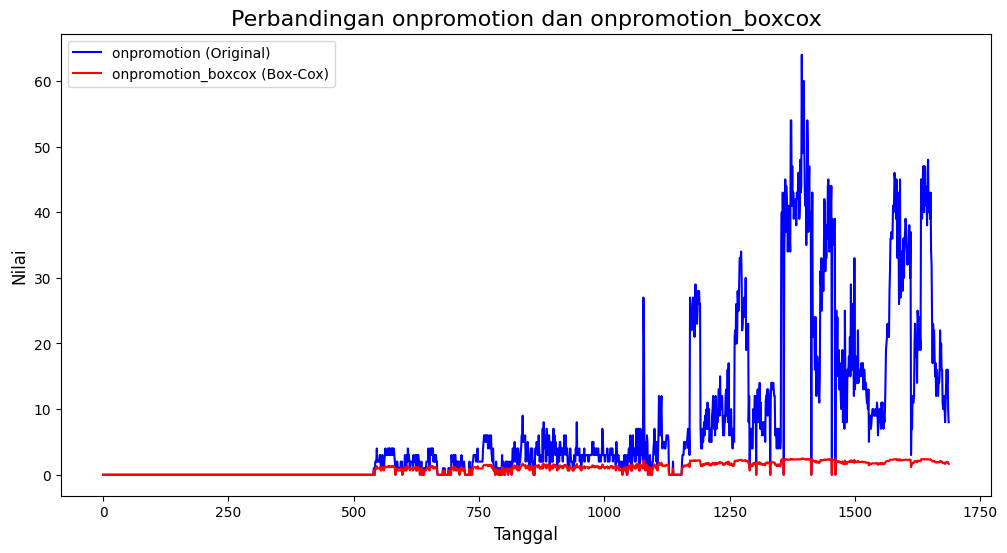

In [188]:
plt.figure(figsize=(12, 6))

plt.plot(df_cleaning_new.index, df_cleaning_new['onpromotion'], label='onpromotion (Original)', color='blue')

plt.plot(df_cleaning_new.index, df_cleaning_new['onpromotion_boxcox'], label='onpromotion_boxcox (Box-Cox)', color='red')

plt.title('Perbandingan onpromotion dan onpromotion_boxcox', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Nilai', fontsize=12)

plt.legend()

plt.show()

In [189]:
missing_per_column = df_cleaning_new.isna().sum()
missing_per_column

,0
date,0
id,4
store_nbr,0
family,0
sales,0
onpromotion,0
dcoilwtico,525
dcoilwtico_interpolate,4
onpromotion_boxcox,0


In [190]:
full_date_range = pd.date_range(start=df_cleaning_new['date'].min(), end=df_cleaning_new['date'].max(), freq='D')

missing_dates = full_date_range.difference(df_cleaning_new['date'])
missing_dates

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [191]:
df_cleaning_new['dcoilwtico_interpolate'] = (
    df_cleaning_new['dcoilwtico']
    .interpolate(method='polynomial', order=2)
    .bfill()
)

In [192]:
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error

df_cleaning_new['date'] = pd.to_datetime(df_cleaning_new['date'])

df_cleaning_new.set_index('date', inplace=True)

endog = df_cleaning_new[['sales', 'onpromotion_boxcox']]
exog = df_cleaning_new[['dcoilwtico_interpolate']]

train_size = int(len(df_cleaning) * 0.8)
train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]

In [193]:
train_endog

,sales,onpromotion_boxcox
date,,
2013-01-01,0.0,0.000000
2013-01-02,1810.0,0.000000
2013-01-03,1305.0,0.000000
2013-01-04,1159.0,0.000000
2013-01-05,1257.0,0.000000
...,...,...
2015-07-15,1058.0,1.298555
2015-07-16,896.0,1.298555
2015-07-17,996.0,0.630668


In [194]:
test_endog

,sales,onpromotion_boxcox
date,,
2015-07-20,1008.0,0.630668
2015-07-21,977.0,1.151165
2015-07-22,936.0,1.298555
2015-07-23,904.0,1.151165
2015-07-24,796.0,0.947195
...,...,...
2017-08-11,775.0,1.963158
2017-08-12,686.0,1.905055
2017-08-13,927.0,1.963158


In [195]:
train_exog

,dcoilwtico_interpolate
date,
2013-01-01,93.140000
2013-01-02,93.140000
2013-01-03,92.970000
2013-01-04,93.120000
2013-01-05,93.205338
...,...
2015-07-15,51.400000
2015-07-16,50.900000
2015-07-17,50.880000


In [196]:
import itertools
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error
from scipy.special import inv_boxcox
from scipy.stats import boxcox
import pandas as pd

# Tetapkan frekuensi pada data time series (contoh: harian)
df_cleaning_new.index = pd.date_range(start='2022-01-01', periods=len(df_cleaning_new), freq='D')

# Grid search untuk parameter p dan q
p_values = range(1, 5)  # Order autoregressive
q_values = range(0, 4)  # Order moving average
best_score = float("inf")
best_cfg = None
best_model = None

# Hitung rata-rata aktual untuk normalisasi
mean_sales = test_endog['sales'].mean()
mean_promo = test_endog['onpromotion_boxcox'].mean()

# Coba semua kombinasi (p, q)
for p, q in itertools.product(p_values, q_values):
    try:
        print(f"Evaluating VARMAX({p},{q})...")

        # Train model VARMAX
        model = VARMAX(train_endog, exog=train_exog, order=(p, q), trend='c')
        model_fit = model.fit(disp=False)

        # Forecast untuk data test
        preds = model_fit.forecast(steps=len(test_endog), exog=test_exog)

        # Kembalikan prediksi 'onpromotion' ke skala data awal
        preds['onpromotion'] = inv_boxcox(preds['onpromotion_boxcox'], lambda_bc) - 1  # Mengurangi 1 kembali
        test_endog.loc[:, 'onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga

        # Hitung MAE antara prediksi dan data aktual
        mae_sales = mean_absolute_error(test_endog['sales'], preds['sales'])
        mae_promo = mean_absolute_error(test_endog['onpromotion'], preds['onpromotion'])

        # Normalisasi MAE
        mae_sales_norm = mae_sales / mean_sales
        mae_promo_norm = mae_promo / mean_promo
        mae_normalized = mae_sales_norm + mae_promo_norm  # Gabungkan kesalahan yang telah dinormalisasi

        print(f"VARMAX({p},{q}) - Normalized MAE: {mae_normalized:.4f}")

        # Simpan model dengan MAE terbaik
        if mae_normalized < best_score:
            best_score = mae_normalized
            best_cfg = (p, q)
            best_model = model_fit

    except Exception as e:
        print(f"VARMAX({p},{q}) gagal dilatih: {e}")

print(f"\nBest VARMAX order: {best_cfg} dengan Normalized MAE: {best_score:.4f}")

Evaluating VARMAX(1,0)...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
<ipython-input-196-cfa504cbb47f>:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_endog.loc[:, 'onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: Valu

VARMAX(1,0) - Normalized MAE: 8.5332
Evaluating VARMAX(1,1)...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(date

VARMAX(1,1) - Normalized MAE: 8.5327
Evaluating VARMAX(1,2)...


...

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(date

VARMAX(4,2) - Normalized MAE: 8.4624
Evaluating VARMAX(4,3)...


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


VARMAX(4,3) - Normalized MAE: 8.4366

Best VARMAX order: (3, 3) dengan Normalized MAE: 8.3513


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


In [197]:

# Gunakan model terbaik untuk prediksi
test_preds = best_model.forecast(steps=len(test_endog), exog=test_exog)

# Kembalikan prediksi 'onpromotion' ke skala data awal untuk visualisasi
test_preds['onpromotion'] = inv_boxcox(test_preds['onpromotion_boxcox'], lambda_bc) - 1

test_preds

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


,sales,onpromotion_boxcox,onpromotion
2015-07-20,1239.498799,0.797667,1.463015
2015-07-21,1145.156120,0.831664,1.573560
2015-07-22,1107.520642,0.817124,1.525523
2015-07-23,1112.314566,0.836117,1.588506
2015-07-24,1126.822841,0.851323,1.640383
...,...,...,...
2017-08-11,1132.669732,1.100090,2.713880
2017-08-12,1132.754265,1.099272,2.709515
2017-08-13,1133.927369,1.099759,2.712114
2017-08-14,1135.065306,1.100133,2.714110


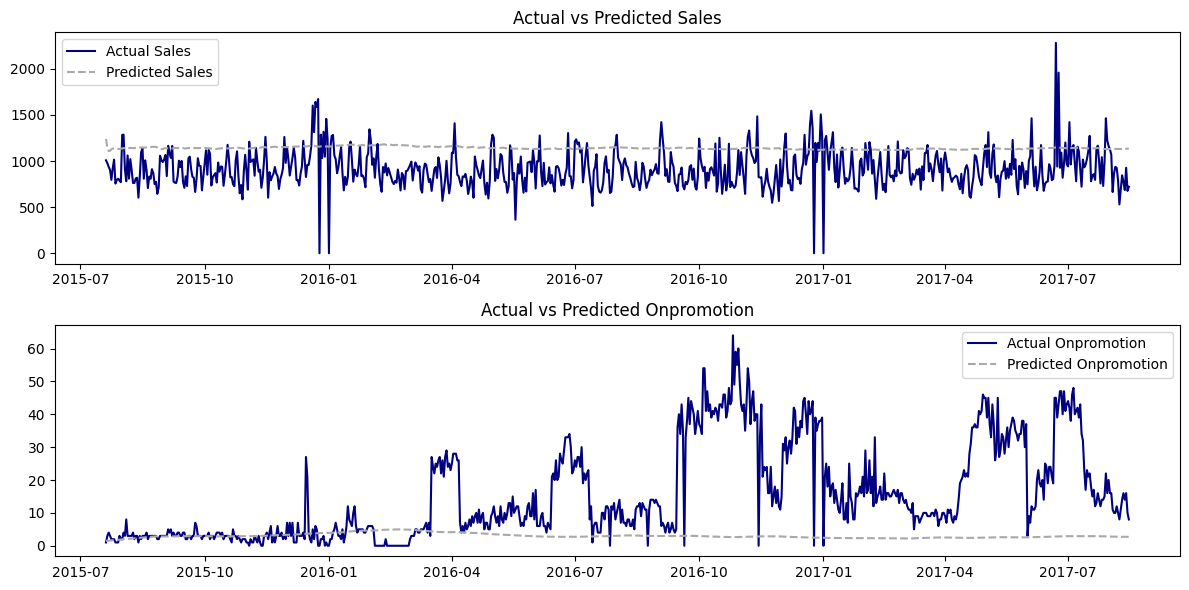

In [198]:

# Plot hasil prediksi vs actual
plt.figure(figsize=(12, 6))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_endog.index, test_endog['sales'], label='Actual Sales', color='navy')
plt.plot(test_endog.index, test_preds['sales'], label='Predicted Sales', color='darkgrey', linestyle='dashed')
plt.title('Actual vs Predicted Sales')
plt.legend()

# Plot Onpromotion (sudah dalam skala asli)
plt.subplot(2, 1, 2)
plt.plot(test_endog.index, test_endog['onpromotion'], label='Actual Onpromotion', color='navy')
plt.plot(test_endog.index, test_preds['onpromotion'], label='Predicted Onpromotion', color='darkgrey', linestyle='dashed')
plt.title('Actual vs Predicted Onpromotion')
plt.legend()

plt.tight_layout()
plt.show()

In [199]:

from sklearn.metrics import mean_squared_error

# Menghitung RMSE untuk Sales
rmse_sales = np.sqrt(mean_squared_error(test_endog['sales'], test_preds['sales']))

# Menghitung RMSE untuk Onpromotion
rmse_onpromotion = np.sqrt(mean_squared_error(test_endog['onpromotion'], test_preds['onpromotion']))

# Menampilkan RMSE
print(f'RMSE for Sales: {rmse_sales:.4f}')
print(f'RMSE for Onpromotion: {rmse_onpromotion:.4f}')

RMSE for Sales: 305.2193
RMSE for Onpromotion: 19.2331


In [200]:
test_preds = best_model.forecast(steps=len(test_endog), exog=test_exog)

# Kembalikan prediksi 'onpromotion' ke skala data awal untuk visualisasi
test_preds['onpromotion'] = inv_boxcox(test_preds['onpromotion_boxcox'], lambda_bc) - 1

test_preds

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


,sales,onpromotion_boxcox,onpromotion
2015-07-20,1239.498799,0.797667,1.463015
2015-07-21,1145.156120,0.831664,1.573560
2015-07-22,1107.520642,0.817124,1.525523
2015-07-23,1112.314566,0.836117,1.588506
2015-07-24,1126.822841,0.851323,1.640383
...,...,...,...
2017-08-11,1132.669732,1.100090,2.713880
2017-08-12,1132.754265,1.099272,2.709515
2017-08-13,1133.927369,1.099759,2.712114
2017-08-14,1135.065306,1.100133,2.714110


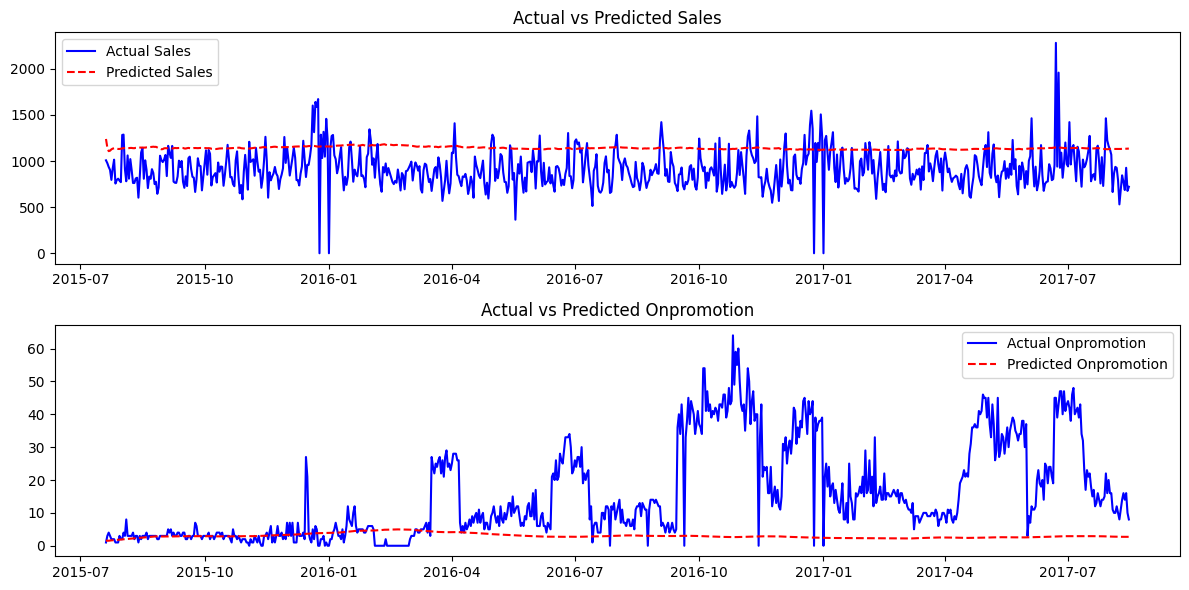

In [201]:

# Plot hasil prediksi vs actual
plt.figure(figsize=(12, 6))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_endog.index, test_endog['sales'], label='Actual Sales', color='blue')
plt.plot(test_endog.index, test_preds['sales'], label='Predicted Sales', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Sales')
plt.legend()

# Plot Onpromotion (sudah dalam skala asli)
plt.subplot(2, 1, 2)
plt.plot(test_endog.index, test_endog['onpromotion'], label='Actual Onpromotion', color='blue')
plt.plot(test_endog.index, test_preds['onpromotion'], label='Predicted Onpromotion', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Onpromotion')
plt.legend()

plt.tight_layout()
plt.show()

In [202]:

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import time
from sklearn.metrics import mean_squared_error

# Preprocessing
scaler_endog = MinMaxScaler()
scaler_exog = MinMaxScaler()

# Pisahkan variabel endogen dan eksogen
endog = df_cleaning_new[['sales', 'onpromotion']]
exog = df_cleaning_new[['dcoilwtico_interpolate']]

# Pisahkan data menjadi train dan test
train_size = int(len(df_cleaning) * 0.8)
train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]

# Scaling the data (already done earlier)
endog_scaled = scaler_endog.fit_transform(endog)
exog_scaled = scaler_exog.fit_transform(exog)

In [203]:
print(f"endog_scaled shape: {endog_scaled.shape}")  # (1688, 2)

# Combine exogenous (exog) and endogenous (endog) features into x
x = np.concatenate([exog_scaled, endog_scaled], axis=1)

# The target variable 'y' is the endog_scaled
y = endog_scaled  # 'sales' and 'onpromotion' as the target (2 columns)

endog_scaled shape: (1688, 2)


In [204]:
def load_data(X, seq_len, train_size=0.9):
    amount_of_features = X.shape[1]
    X_mat = X
    sequence_length = seq_len + 1
    data = []

    for index in range(len(X_mat) - sequence_length):
        data.append(X_mat[index: index + sequence_length])

    data = np.array(data)
    train_split = int(round(train_size * data.shape[0]))
    train_data = data[:train_split, :]

    x_train = train_data[:, :-1]
    y_train = train_data[:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    x_test = data[train_split:, :-1]
    y_test = data[train_split:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    # Check shapes before reshaping
    print(f"x_train shape (before reshape): {x_train.shape}")
    print(f"y_train shape (before reshape): {y_train.shape}")

    # Make sure y_train and y_test have 2 columns (for 'sales' and 'onpromotion')
    assert y_train.shape[1] == 2, "y_train should have 2 columns (sales and onpromotion)"
    assert y_test.shape[1] == 2, "y_test should have 2 columns (sales and onpromotion)"

    # Reshape x_train and x_test to 3D arrays for LSTM input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], amount_of_features))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], amount_of_features))

    return x_train, y_train, x_test, y_test

# Setting window size
window = 22
X_train, y_train, X_test, y_test = load_data(x, window)

# Print the shapes of data after loading and reshaping
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

x_train shape (before reshape): (1498, 22, 3)
y_train shape (before reshape): (1498, 2)
X_train shape: (1498, 22, 3), y_train shape: (1498, 2)
X_test shape: (167, 22, 3), y_test shape: (167, 2)


In [205]:
# LSTM Model
model = Sequential()
model.add(LSTM(units=50, input_shape=(window, X_train.shape[2])))
model.add(Dropout(0.2))

# Output layer with 2 units for 'sales' and 'onpromotion'
model.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit the model
start = time.time()
history = model.fit(X_train, y_train, epochs=100, batch_size=35, validation_split=0.05, verbose=1)
print('Compilation time: ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0762 - val_loss: 0.0404
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0154 - val_loss: 0.0176
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0095 - val_loss: 0.0164
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0089 - val_loss: 0.0158
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0084 - val_loss: 0.0143
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0072 - val_loss: 0.0145
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0071 - val_loss: 0.0143
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0069 - val_loss: 0.0151
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0072 - val_loss: 0.0140
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0072 - val_loss: 0.0142
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0068 - val_loss: 0.0139
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

In [206]:

# Predictions
trainPredict = model.predict(X_train)
testPredict = model.predict(X_test)

# Inverse transform to get the actual values
trainPredict = scaler_endog.inverse_transform(trainPredict)
trainY = scaler_endog.inverse_transform(y_train)
testPredict = scaler_endog.inverse_transform(testPredict)
testY = scaler_endog.inverse_transform(y_test)

# Plotting
plot_predicted_sales = testPredict[:, 0].reshape(-1, 1)
plot_predicted_onpromotion = testPredict[:, 1].reshape(-1, 1)

plot_actual_sales = testY[:, 0].reshape(-1, 1)
plot_actual_onpromotion = testY[:, 1].reshape(-1, 1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [207]:
# Print shapes for verification
print(f"Plot actual sales shape: {plot_actual_sales.shape}")
print(f"Plot predicted sales shape: {plot_predicted_sales.shape}")

Plot actual sales shape: (167, 1)
Plot predicted sales shape: (167, 1)


In [208]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales = mean_squared_error(trainY[:, 0], trainPredict[:, 0]) ** 0.5
testScore_sales = mean_squared_error(testY[:, 0], plot_predicted_sales[:, 0]) ** 0.5

trainScore_onpromotion = mean_squared_error(trainY[:, 1], trainPredict[:, 1]) ** 0.5
testScore_onpromotion = mean_squared_error(testY[:, 1], plot_predicted_onpromotion[:, 0]) ** 0.5

In [209]:
print(f'Train Score for sales: {trainScore_sales:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion:.2f} RMSE')

Train Score for sales: 194.32 RMSE
Test Score for sales: 212.50 RMSE
Train Score for onpromotion: 3.52 RMSE
Test Score for onpromotion: 5.15 RMSE


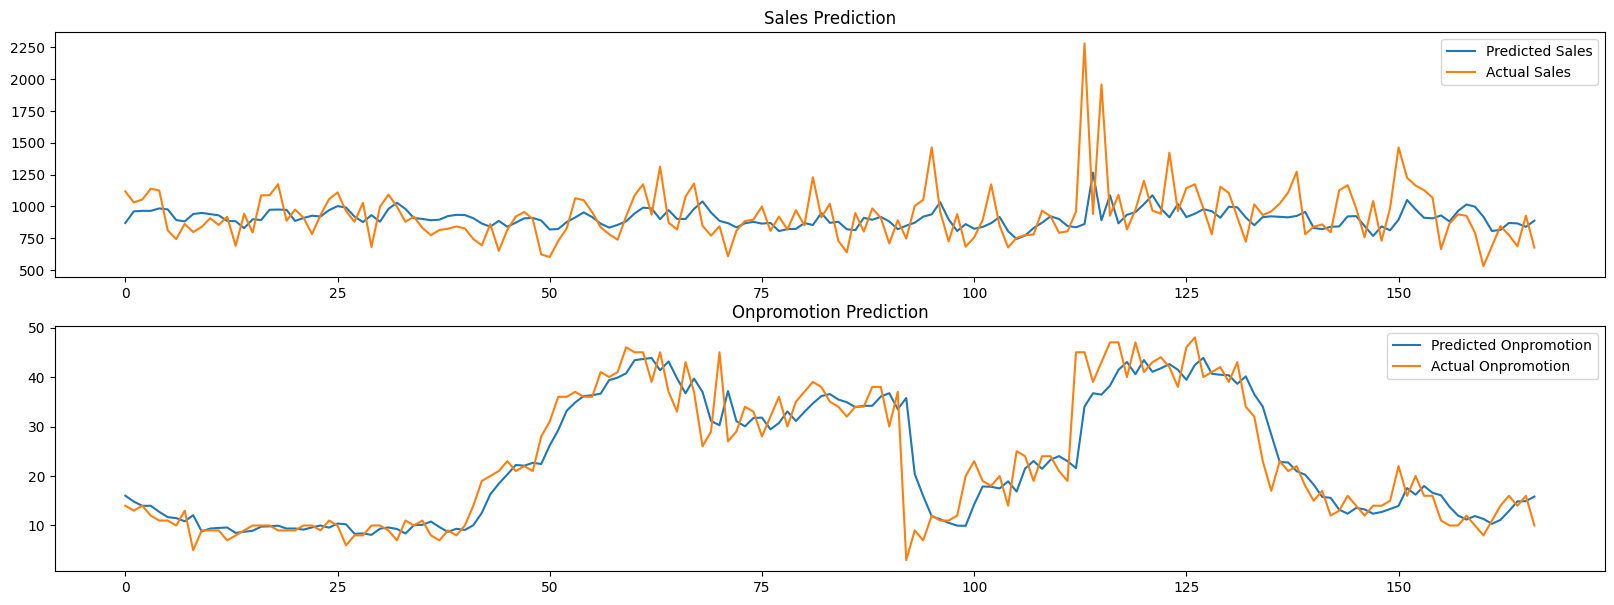

In [210]:
# Plot the results for both targets
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(plot_predicted_sales), label='Predicted Sales')
plt.plot(pd.DataFrame(plot_actual_sales), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(plot_predicted_onpromotion), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(plot_actual_onpromotion), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction')

plt.show()

In [211]:
from tensorflow.keras.callbacks import EarlyStopping

# Stacked LSTM Model with Dropout
model2 = Sequential()

# First LSTM layer
model2.add(LSTM(units=50, return_sequences=True, input_shape=(window, X_train.shape[2])))
model2.add(Dropout(0.2))

# Second LSTM layer
model2.add(LSTM(units=50, return_sequences=True))
model2.add(Dropout(0.2))

# Third LSTM layer
model2.add(LSTM(units=50))
model2.add(Dropout(0.2))

# Dense layers
model2.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model2.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs (sales and onpromotion)

earlystop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
callbacks_list = [earlystop]

# Compile the model
model2.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
start = time.time()
history = model2.fit(X_train, y_train, epochs=100, batch_size=35, validation_split=0.05, verbose=1)
print('Training time: ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0716 - val_loss: 0.0498
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0168 - val_loss: 0.0226
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0116 - val_loss: 0.0217
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0103 - val_loss: 0.0163
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0090 - val_loss: 0.0313
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0084 - val_loss: 0.0149
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0082 - val_loss: 0.0272
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0078 - val_loss: 0.0145
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0076 - val_loss: 0.0135
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0077 - val_loss: 0.0154
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0079 - val_loss: 0.0131
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0

In [212]:
# Predictions
trainPredict = model2.predict(X_train)
testPredict = model2.predict(X_test)

# Inverse transform to get actual values
trainPredict = scaler_endog.inverse_transform(trainPredict)
trainY = scaler_endog.inverse_transform(y_train)
testPredict = scaler_endog.inverse_transform(testPredict)
testY = scaler_endog.inverse_transform(y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [213]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales2 = mean_squared_error(trainY[:, 0], trainPredict[:, 0]) ** 0.5
testScore_sales2 = mean_squared_error(testY[:, 0], testPredict[:, 0]) ** 0.5

trainScore_onpromotion2 = mean_squared_error(trainY[:, 1], trainPredict[:, 1]) ** 0.5
testScore_onpromotion2 = mean_squared_error(testY[:, 1], testPredict[:, 1]) ** 0.5

In [214]:
print(f'Train Score for sales: {trainScore_sales2:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales2:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion2:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion2:.2f} RMSE')

Train Score for sales: 215.27 RMSE
Test Score for sales: 215.26 RMSE
Train Score for onpromotion: 3.38 RMSE
Test Score for onpromotion: 7.11 RMSE


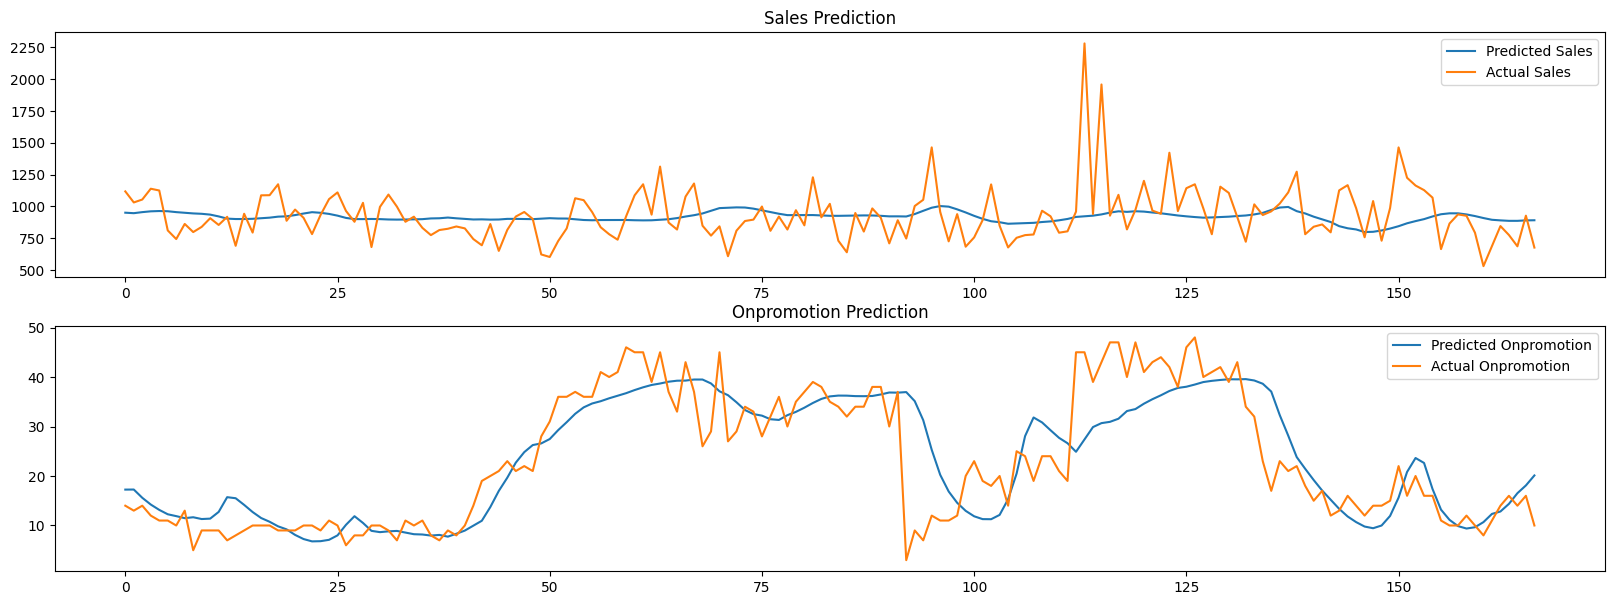

In [215]:
# Plot the results
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(testPredict[:, 0]), label='Predicted Sales')
plt.plot(pd.DataFrame(testY[:, 0]), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(testPredict[:, 1]), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(testY[:, 1]), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction')

plt.show()

In [216]:
# Membuat dictionary dengan hasil evaluasi RMSE untuk masing-masing model
rmse_comparison = {
    "Model": ["Model VARMAX", "Model VARMAX", "Model Single Layer LSTM", "Model Single Layer LSTM", "Model Single Layer LSTM", "Model Single Layer LSTM", "Model Stacked LSTM Using Dropout", "Model Stacked LSTM Using Dropout", "Model Stacked LSTM Using Dropout", "Model Stacked LSTM Using Dropout"],
    "Metric": ["Train VARMAX", "Test VARMAX","Train RMSE (Sales)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Train RMSE (Onpromotion)",
               "Train RMSE (Sales)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Train RMSE (Onpromotion)"],
    "RMSE Value": [
        rmse_sales, rmse_onpromotion, trainScore_sales, testScore_sales, trainScore_onpromotion, testScore_onpromotion,
        trainScore_sales2, testScore_sales2, trainScore_onpromotion2, testScore_onpromotion2
    ]
}

# Membuat DataFrame untuk perbandingan
rmse_df = pd.DataFrame(rmse_comparison)
rmse_df

,Model,Metric,RMSE Value
0,Model VARMAX,Train VARMAX,305.219300
1,Model VARMAX,Test VARMAX,19.233078
2,Model Single Layer LSTM,Train RMSE (Sales),194.315350
3,Model Single Layer LSTM,Test RMSE (Sales),212.501434
4,Model Single Layer LSTM,Test RMSE (Onpromotion),3.522083
5,Model Single Layer LSTM,Train RMSE (Onpromotion),5.146984
6,Model Stacked LSTM Using Dropout,Train RMSE (Sales),215.268164
7,Model Stacked LSTM Using Dropout,Test RMSE (Sales),215.262747
8,Model Stacked LSTM Using Dropout,Test RMSE (Onpromotion),3.380031
9,Model Stacked LSTM Using Dropout,Train RMSE (Onpromotion),7.105964


In [220]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import time

# Definisi scaler dan scaling data
y_scaler = MinMaxScaler(feature_range=(0, 1))
y_train_scaled = y_scaler.fit_transform(y_train)

window = 22

model3 = Sequential()
model3.add(Bidirectional(LSTM(units=50), input_shape=(window, 3)))
model3.add(Dropout(0.2))
model3.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model3.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))

earlystop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
callbacks_list = [earlystop]

model3.compile(optimizer='adam', loss='mean_squared_error')

start = time.time()
# Gunakan y_train_scaled untuk training
history = model3.fit(X_train, y_train_scaled, epochs=100, batch_size=35,
                    validation_split=0.05, verbose=1, callbacks=callbacks_list)
print('compilation time : ', time.time() - start)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0927 - val_loss: 0.0494
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0158 - val_loss: 0.0209
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0116 - val_loss: 0.0197
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0108 - val_loss: 0.0188
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0104 - val_loss: 0.0198
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0100 - val_loss: 0.0181
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0102 - val_loss: 0.0220
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0095 - val_loss: 0.0179
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0093 - val_loss: 0.0178
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0087 - val_loss: 0.0176
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0089 - val_loss: 0.0203
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

<Axes: >

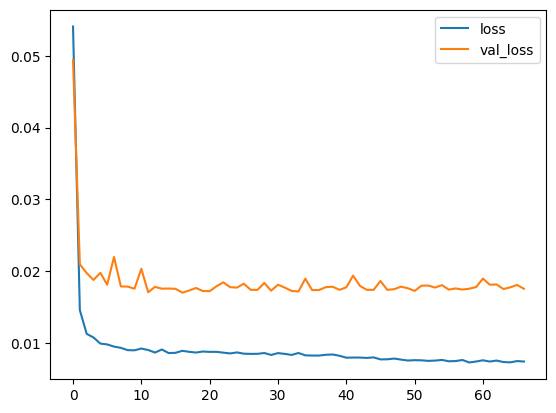

In [221]:
%matplotlib inline
losses = pd.DataFrame(history.history)
losses.plot()

In [222]:
# Prediksi
trainPredict = model3.predict(X_train)
testPredict = model3.predict(X_test)

# Inverse transform
trainPredict = y_scaler.inverse_transform(trainPredict)
trainY = y_scaler.inverse_transform(y_train)  # Hapus brackets
testPredict = y_scaler.inverse_transform(testPredict)
testY = y_scaler.inverse_transform(y_test)    # Hapus brackets

# Reshape untuk plotting
plot_predicted = testPredict[:, 0].reshape(-1, 1)  # Ambil kolom pertama
plot_actual = testY[:, 0].reshape(-1, 1)          # Ambil kolom pertama
print(plot_actual.shape)
print(plot_predicted.shape)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
(167, 1)
(167, 1)


In [228]:
trainScore = mean_squared_error(trainY[:, 0], trainPredict[:, 0]) ** .5  # Menggunakan trainY[:, 0]
print('Train Score: %.2f RMSE' % (trainScore))

testScore = mean_squared_error(testY[:, 0], testPredict[:, 0]) ** .5   # Menggunakan testY[:, 0]
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 0.11 RMSE
Test Score: 0.11 RMSE


In [224]:
from sklearn.metrics import mean_squared_error

# Check dimensi data
print("trainY shape:", trainY.shape)
print("trainPredict shape:", trainPredict.shape)
print("testY shape:", testY.shape)
print("testPredict shape:", testPredict.shape)

# Hitung RMSE tanpa menggunakan [0]
trainScore = mean_squared_error(trainY[:, 0], trainPredict[:, 0]) ** 0.5
print('Train Score: %.2f RMSE' % (trainScore))
testScore = mean_squared_error(testY[:, 0], testPredict[:, 0]) ** 0.5
print('Test Score: %.2f RMSE' % (testScore))

trainY shape: (1498, 2)
trainPredict shape: (1498, 2)
testY shape: (167, 2)
testPredict shape: (167, 2)
Train Score: 0.11 RMSE
Test Score: 0.11 RMSE


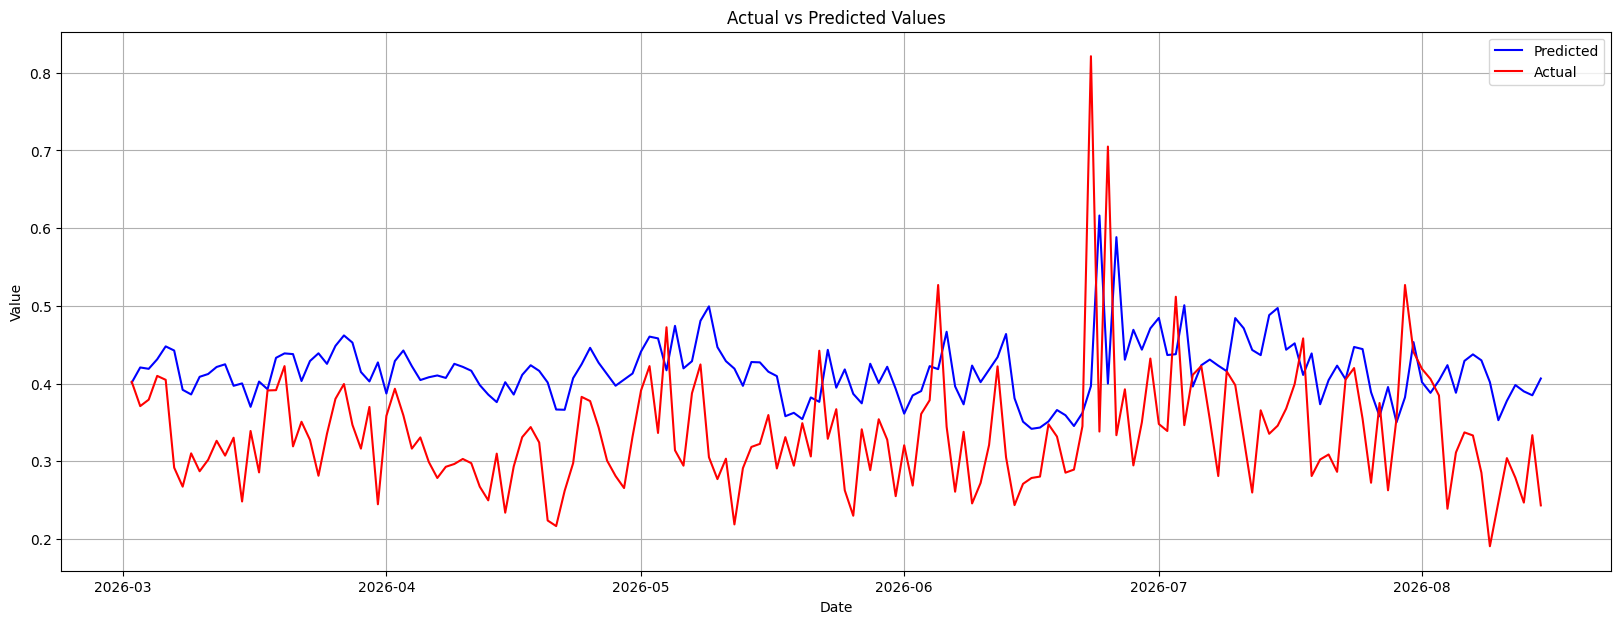

In [230]:
plot_x = df_cleaning_new.index[-len(plot_predicted):]

plt.figure(figsize=(20,7))
plt.plot(plot_x, plot_predicted, label='Predicted', color='blue')
plt.plot(plot_x, plot_actual, label='Actual', color='red')
plt.title('Actual vs Predicted Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='best')
plt.grid(True)
plt.show()